# SMS SPAM CLASSIFIER PROJECT

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("./dataset/spam.csv", encoding="latin-1")

In [3]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2146,ham,So can collect ur laptop?,NaN,NaN,NaN
3772,ham,I came hostel. I m going to sleep. Plz call me...,NaN,NaN,NaN
3858,spam,Win the newest åÒHarry Potter and the Order of...,NaN,NaN,NaN
5279,ham,"Helloooo... Wake up..! \Sweet\"" \""morning\"" \""...",NaN,NaN,NaN
655,ham,Tell them the drug dealer's getting impatient,NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

## Steps:
1. Data Cleaning
2. EDA
3. Text Preprossesing
4. Model Building
5. Evaluation
6. Improvent
7. Website
8. Deployment

## 1. DATA CLEANING

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# Drop last 3 columns - Pretty much useless
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"], inplace=True)

In [7]:
df.sample(5, random_state=4)

,v1,v2
4004,ham,", ow u dey.i paid 60,400thousad.i told u woul..."
2276,ham,Love you aathi..love u lot..
4498,spam,"SMS SERVICES. for your inclusive text credits,..."
3755,ham,Yes:)here tv is always available in work place..
111,ham,Going for dinner.msg you after.


In [8]:
# Renaming columns v1,v2 as they are not descriptive
df.rename(columns={"v1" : "target", "v2":"text"}, inplace=True)

In [9]:
df.sample(5)

,target,text
1725,ham,You know there is. I shall speak to you in &l...
3701,ham,Hey loverboy! I love you !! I had to tell ... ...
5337,ham,My birthday is on feb &lt;#&gt; da. .
5364,spam,Call 09095350301 and send our girls into eroti...
1817,ham,Well i will watch shrek in 3D!!B)


In [10]:
# We need integer target values so lets transform those
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [11]:
df["target"] = encoder.fit_transform(df["target"])

In [12]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# Missing values check
df.isnull().sum()

target    0
text      0
dtype: int64

In [14]:
# Check for duplicate values
df.duplicated().sum()

np.int64(403)

In [15]:
# Remove duplicate
df.drop_duplicates(keep='first', inplace=True)

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5169, 2)

## 2. EDA

In [18]:
# Check percent of data that is spam and that is ham
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

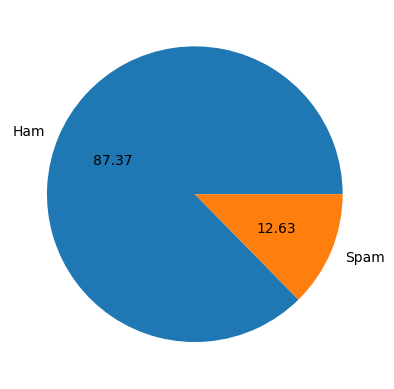

In [19]:
# we could create a pie chart to show the balance
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels = ["Ham","Spam"], autopct="%0.2f")
plt.show()

- Data is Imbalanced

In [20]:
import nltk

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bhand\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

We will create new columns in df
1. Number of characters in the text
2. Number of words in the sms
3. Number of sentenses in the sms

In [23]:
# 1
df['num_characters'] = df['text'].apply(len)

In [24]:
df.head(5)

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
# 2
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [26]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [27]:
# 3
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))


In [28]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [29]:
# Overall Analysis
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
# Comparing only Ham messages
df[df['target'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
df[df['target'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [32]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

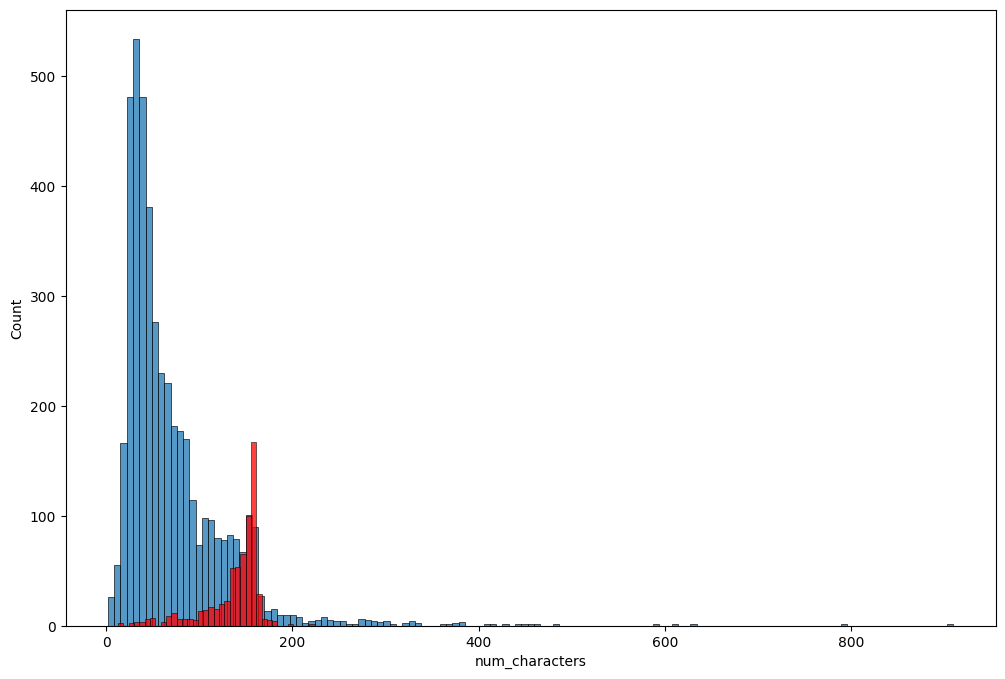

In [33]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

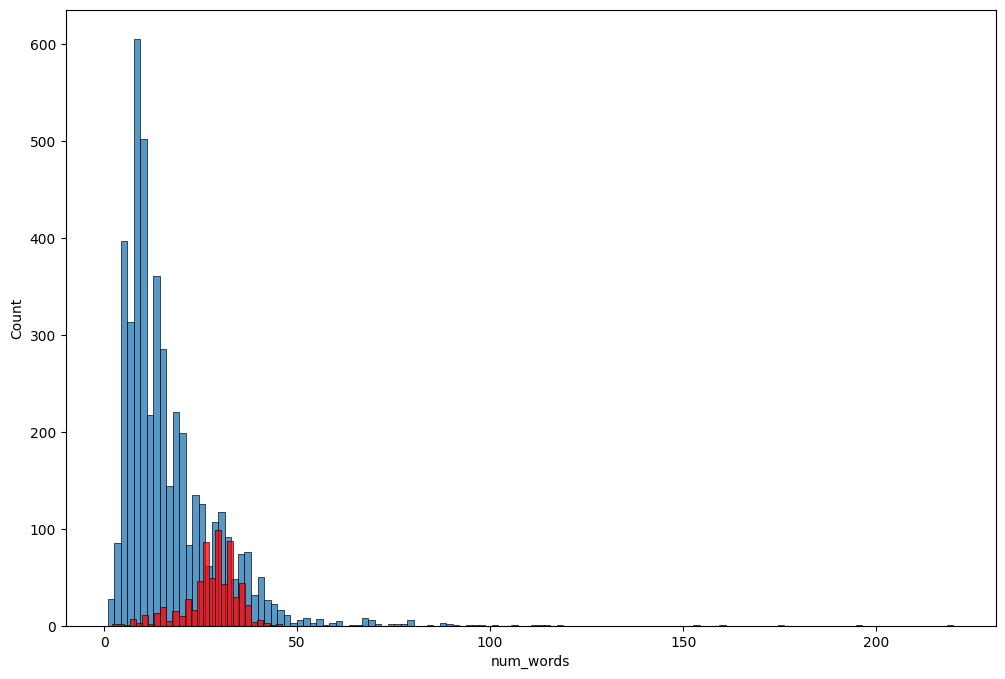

In [34]:
plt.figure(figsize=(12,8))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

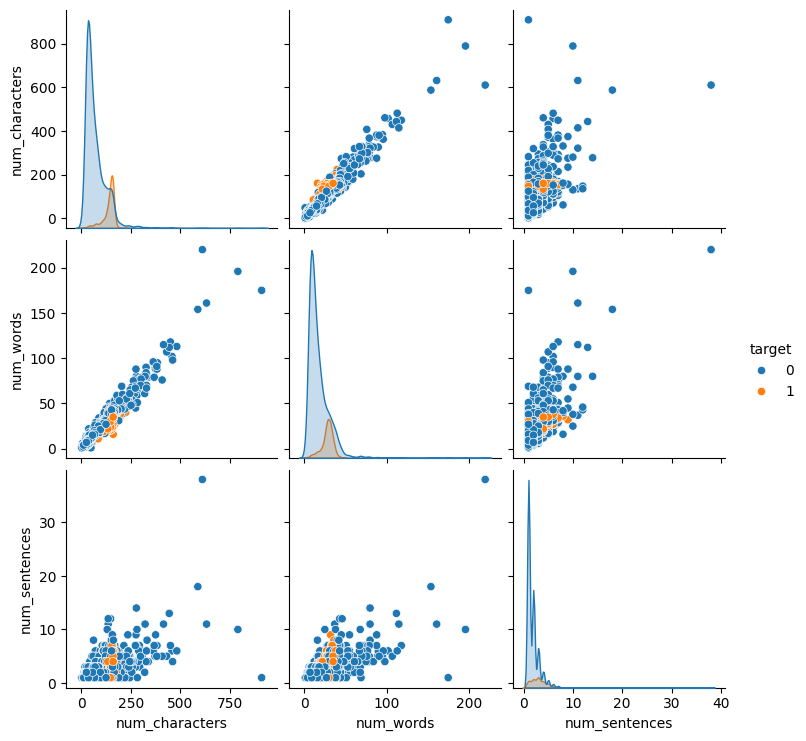

In [35]:
sns.pairplot(df,hue='target')

In [36]:
df[["target","num_characters","num_words","num_sentences"]].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

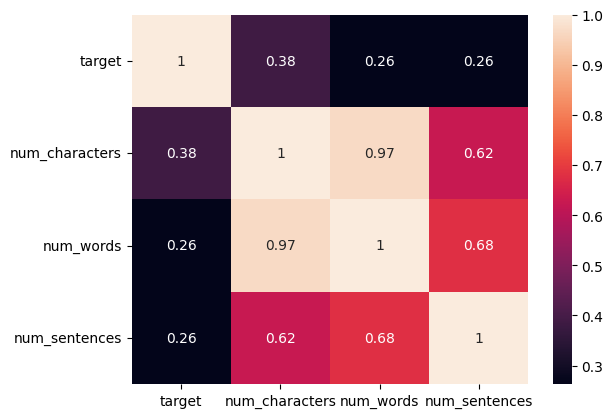

In [37]:
sns.heatmap(df[["target","num_characters","num_words","num_sentences"]].corr(), annot=True)

- From here we can know that num_sentences, num_words, num_chars have a high correlation with each other. When modelling we cant pass all the 3 columns as input due to multi-collinearity so we have to choose 1.
- So what do we choose? The one that has the highest correlation with target! So that is num_characters

## 3. Data Preprocessing
- Lower case
- Tokenization
- Removing special chars
- Removing stop words and punctuation
- Stemming

In [38]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [39]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [48]:
# Stemming -> This is the process of reducing a word to its root form. For example, "running" would be reduced to "run". This can help in reducing the dimensionality of the data and improving the performance of machine learning models.
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [53]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words("english") and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return  " ".join(y)

In [54]:
transform_text("I loved the youtube lectures on Machine Learning. How about you?")

'love youtub lectur machin learn'

In [55]:
df['transformed_text'] = df['text'].apply(transform_text)

In [57]:
df.sample(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
2327,1,URGENT! Your mobile number *************** WON...,167,46,5,urgent mobil number bonu caller prize 2nd atte...
2245,0,How did you find out in a way that didn't incl...,70,16,1,find way includ detail
2206,1,"URGENT! Your mobile No 07xxxxxxxxx won a å£2,0...",159,31,5,urgent mobil 07xxxxxxxxx bonu caller prize 2nd...
80,0,"Sorry, I'll call later",22,6,1,sorri call later
5269,1,"If you don't, your prize will go to another cu...",145,32,2,prize go anoth custom c polo ltd suit 373 lond...


## Spam Wordcloud

In [62]:
#word cloud of spam msgs
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [63]:
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=' '))

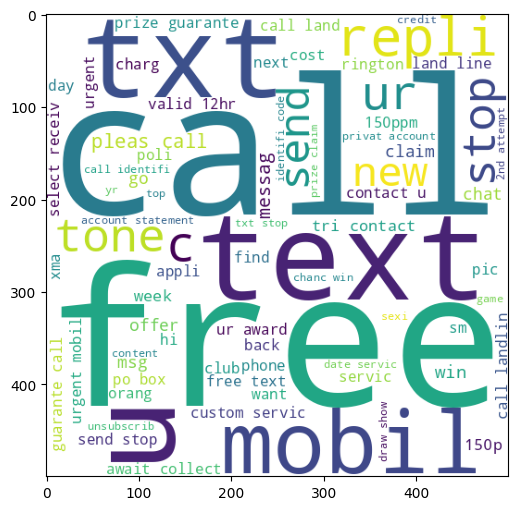

In [65]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

## Ham WordCloud

In [67]:

ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=' '))

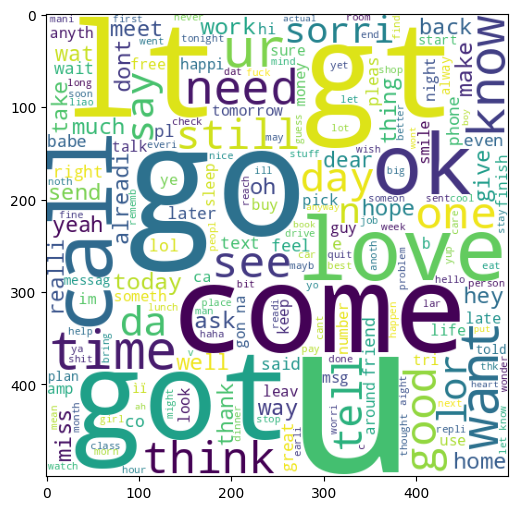

In [69]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [73]:
# Top 30 spam words
spam_corpus = []
for msg in df[df['target']==1]["transformed_text"].tolist():
    for word in msg.split(" "):
        spam_corpus.append(word)

len(spam_corpus)

9939

In [85]:
from collections import Counter
spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
spam_df

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


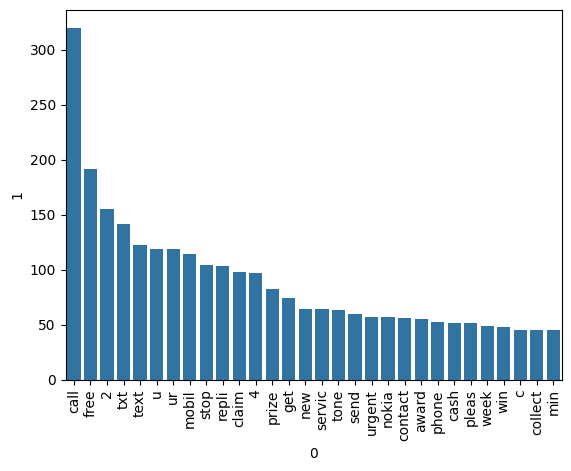

In [90]:
sns.barplot(x=spam_df[0],y=spam_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [93]:
# Top 30 Ham Words
ham_corpus = []
for msg in df[df["target"]==0]["transformed_text"].tolist():
    for word in msg.split():
        ham_corpus.append(word)

len(ham_corpus)

35404

In [103]:
from collections import Counter
Counter(ham_corpus) # This is an object but .most_common(30) is a list so u can pass it into Dataframe
ham_df = pd.DataFrame(Counter(ham_corpus).most_common(30))

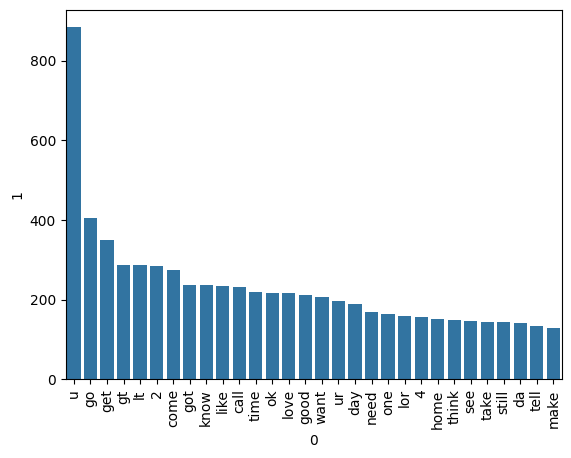

In [107]:
sns.barplot(x=ham_df[0],y=ham_df[1])
plt.xticks(rotation="vertical")
plt.show()

# 4. Model Building

In [153]:
# We will first use Naive Bayes Algorithm since it usually performs best on Textual Data. Our input is the transformed text, a text data and output is numerical target
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer()


In [115]:
df["transformed_text"].shape

(5169,)

In [120]:
myX = set()
for msg in df["transformed_text"]:
    for word in msg.split():
        myX.add(word)

len(myX)

6736

In [136]:
# We can now understand where the shape of this transformed vectotr is coming from
X = cv.fit_transform(df["transformed_text"]).toarray()
X.shape

(5169, 6708)

In [137]:
y = df["target"].values
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [138]:
from sklearn.model_selection import train_test_split

In [139]:
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [140]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [141]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [143]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [144]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [145]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [156]:
X2 = tfidf.fit_transform(df["transformed_text"]).toarray()
X2.shape

(5169, 6708)

In [157]:
X_train,X_test,y_train,y_test = train_test_split(X2, y, test_size=0.2, random_state=2)

In [158]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [159]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [160]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


- Even though the accuracy score of binomial Naive Bayes model is higher, we will select multinomial naive base because in textual data, precision score is usually the important metric to consider and mnb has 1 via the TfidfVectorizer() on X

In [161]:
## Chosen Tfidf with MultinomialNB

In [ ]:
# Now we will try the rest of the classification algorithms to see if we can do better than MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
%pip install xgboost
from xgboost import XGBClassifier

In [163]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5, random_state=2)
lrc = LogisticRegression(solver='liblinear',penalty='l1', random_state=2)
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50, random_state=2)


In [168]:
clfs = {
    "SVC": svc,
    "KNC": knc,
    "MNB": mnb,
    "DTC": dtc,
    "LRC": lrc,
    "RFC": rfc,
    "ABC": abc,
    "GBDT": gbdt,
    "ETC": etc,
    "BC": bc,
    "XGB": xgb
}

In [165]:
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    return accuracy, precision

In [166]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9729206963249516, 0.9741379310344828)

In [170]:
accuracy_scores = []
precision_scores = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    print(f"For {name} Accuracy: {current_accuracy} and Precision: {current_precision}")
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC Accuracy: 0.9729206963249516 and Precision: 0.9741379310344828
For KNC Accuracy: 0.9003868471953579 and Precision: 1.0
For MNB Accuracy: 0.9593810444874274 and Precision: 1.0
For DTC Accuracy: 0.9352030947775629 and Precision: 0.8380952380952381


C:\Users\bhand\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\bhand\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For LRC Accuracy: 0.9516441005802708 and Precision: 0.94
For RFC Accuracy: 0.971953578336557 and Precision: 1.0
For ABC Accuracy: 0.9245647969052224 and Precision: 0.8409090909090909
For GBDT Accuracy: 0.9526112185686654 and Precision: 0.9238095238095239
For ETC Accuracy: 0.9729206963249516 and Precision: 0.9824561403508771
For BC Accuracy: 0.9584139264990329 and Precision: 0.8625954198473282
For XGB Accuracy: 0.9748549323017408 and Precision: 0.9516129032258065


In [171]:
performance_df = pd.DataFrame({"Algorithm": clfs.keys(), "Accuracy": accuracy_scores, "Precision": precision_scores}).sort_values("Precision", ascending=False)
performance_df

,Algorithm,Accuracy,Precision
1,KNC,0.900387,1.000000
2,MNB,0.959381,1.000000
5,RFC,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,XGB,0.974855,0.951613
4,LRC,0.951644,0.940000
7,GBDT,0.952611,0.923810
9,BC,0.958414,0.862595
6,ABC,0.924565,0.840909


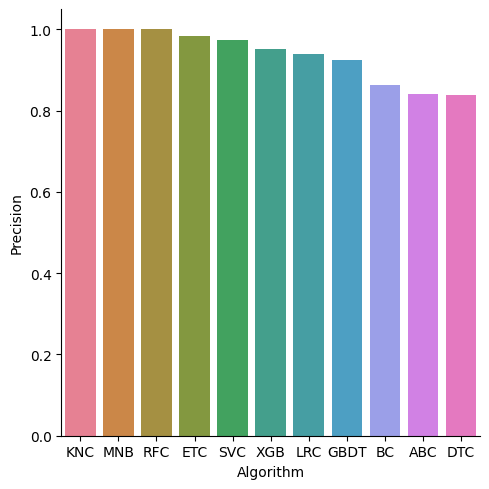

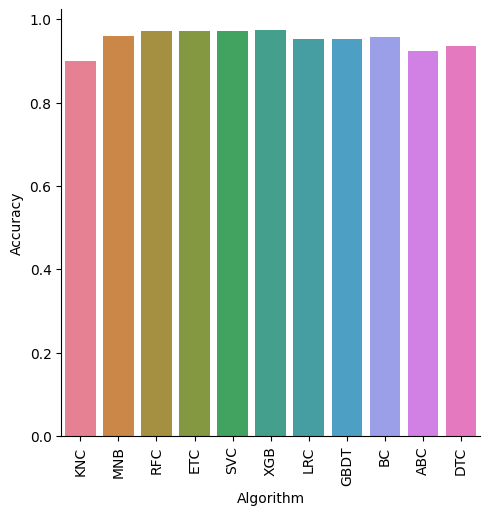

In [177]:
sns.catplot(x="Algorithm", y="Precision", hue="Algorithm", data=performance_df, kind="bar", height=5)
sns.catplot(x="Algorithm", y="Accuracy", hue="Algorithm", data=performance_df, kind="bar", height=5)
plt.xticks(rotation=90)
plt.show()

## Model Improve
### 1. Change the number of max_feature parameter of Tfidf
### 2. Scale X. Using minmax Scalar

(0.9593810444874274, 1.0)